In [2]:
import pandas as pd

In [6]:
df = pd.read_csv("/Users/jennaqasqas/python_decal_sp26/course_assignments/homework8/state_data.csv")

In [7]:
print(df.shape)

(52, 4)


In [8]:
print(df.head())
print(df.tail())

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California
   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


first column is the state. Second column is the state. column 3- latitudue. column 4- longitude. column 5- name.
first state: Alaska.
Last state: Wyoming.
51 entries.
?

In [10]:
median_latitude = df["latitude"].median()
median_longitude = df["longitude"].median()
print(median_latitude, median_longitude)

39.4355155 -89.093198


In [11]:
df["lat_dist"] = abs(df["latitude"] - median_latitude)
df["lon_dist"] = abs(df["longitude"] - median_longitude)

In [12]:
print(df.shape)

(52, 6)


2 more columns!

In [13]:
closest_lat = df.loc[df["lat_dist"].idxmin()]
farthest_lat = df.loc[df["lat_dist"].idxmax()]

closest_lon = df.loc[df["lon_dist"].idxmin()]
farthest_lon = df.loc[df["lon_dist"].idxmax()]

In [14]:
print(f"closest to median latitude: {closest_lat['state']} ({closest_lat['lat_dist']:.2f})")
print(f"farthest from median latitude: {farthest_lat['state']} ({farthest_lat['lat_dist']:.2f})")

print(f"closest to median longitude: {closest_lon['state']} ({closest_lon['lon_dist']:.2f})")
print(f"farthest from median longitude: {farthest_lon['state']} ({farthest_lon['lon_dist']:.2f})")

closest to median latitude: CO (0.11)
farthest from median latitude: AK (24.15)
closest to median longitude: IL (0.31)
farthest from median longitude: HI (66.57)


In [15]:
print(df.describe())

        latitude   longitude   lat_dist   lon_dist
count  52.000000   52.000000  52.000000  52.000000
mean   39.153437  -92.824719   4.815714  14.535330
std     6.967697   19.431647   4.998411  13.280351
min    18.220833 -155.665857   0.114536   0.305330
25%    35.438381 -102.009600   1.564952   6.037732
50%    39.435516  -89.093198   3.890968  11.903743
75%    43.220246  -78.291302   6.133912  17.832342
max    63.588753  -66.590149  24.153237  66.572659


i found .describe() in the official pandas documentation under DataFrame methods. This function summarizes numerical data by showing count, mean, standard deviation, min, max, and quartiles. It's usseful for extracting a statistical overview about the spread of your data.

## 3. Seaborn

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
df = sns.load_dataset("penguins")

df = df.dropna()


In [23]:
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Shape: (333, 7)
Rows: 333
Columns: 7


In [24]:
print(df.head())
print(df.tail())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
4       3450.0  Female  
5       3650.0    Male  
    species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
338  Gentoo  Biscoe            47.2           13.7              214.0   
340  Gentoo  Biscoe            46.8           14.3              215.0   
341  Gentoo  Biscoe            50.4           15.7              222.0   
342  Gentoo  Biscoe            45.2           14.8              212.0   
343  Gentoo  Biscoe            49.9     

In [21]:
print("columns:", df.columns.tolist())

columns: ['species', 'island']


species: penguin species. island = island the penguin is observed. bill_length: bill length. bill_depth_mm: penguin bill depth in mm. flipper_length_mm: flipper lentgh in mm

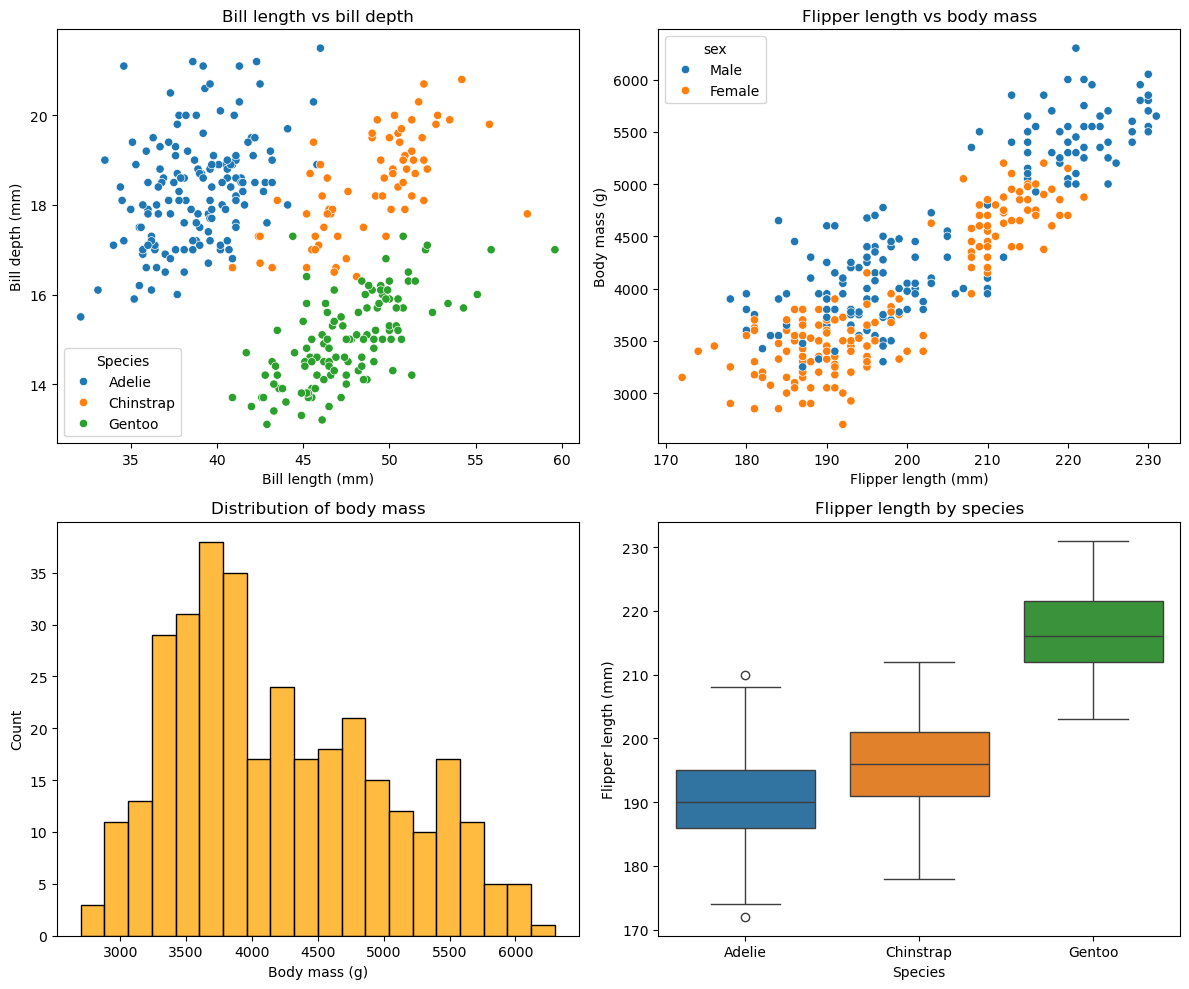

In [28]:
plt.figure(figsize=(12, 10))

# top left
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species")
plt.title("Bill length vs bill depth")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.legend(title="Species")

# top right
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g", hue="sex")
plt.title("Flipper length vs body mass")
plt.xlabel("Flipper length (mm)")
plt.ylabel("Body mass (g)")

# bottom left
plt.subplot(2, 2, 3)
sns.histplot(data=df, x="body_mass_g", bins=20, color="orange")
plt.title("Distribution of body mass")
plt.xlabel("Body mass (g)")
plt.ylabel("Count")

# bottom right
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x="species", y="flipper_length_mm", hue="species")
plt.title("Flipper length by species")
plt.xlabel("Species")
plt.ylabel("Flipper length (mm)")

plt.tight_layout()
plt.show()

The top left plot represents the different penguin species' bill sizes. You get information on the general bill length and depth for the different species and can see how it compares.
The top right plot shows each species' flipper length as a function of its body mass. The bottom left graph shows a distributoon of body mass for all of the penguins. The "Flipper length by species" figure shows the spread of the flipper lenght for all 3 species.